## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [134]:
import requests

# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230
temper = 'temperature_2m'

url = f"https://api.open-meteo.com/v1/forecast?"  # Aquí vienen el resto de los parámetros

url_loc = url + '&latitude=' + str(latitude) + '&longitude=' + str(longitude) + '&hourly=' + temper

response = requests.get(url_loc)
response.json()['hourly']
# url_loc

{'time': ['2026-03-23T00:00',
  '2026-03-23T01:00',
  '2026-03-23T02:00',
  '2026-03-23T03:00',
  '2026-03-23T04:00',
  '2026-03-23T05:00',
  '2026-03-23T06:00',
  '2026-03-23T07:00',
  '2026-03-23T08:00',
  '2026-03-23T09:00',
  '2026-03-23T10:00',
  '2026-03-23T11:00',
  '2026-03-23T12:00',
  '2026-03-23T13:00',
  '2026-03-23T14:00',
  '2026-03-23T15:00',
  '2026-03-23T16:00',
  '2026-03-23T17:00',
  '2026-03-23T18:00',
  '2026-03-23T19:00',
  '2026-03-23T20:00',
  '2026-03-23T21:00',
  '2026-03-23T22:00',
  '2026-03-23T23:00',
  '2026-03-24T00:00',
  '2026-03-24T01:00',
  '2026-03-24T02:00',
  '2026-03-24T03:00',
  '2026-03-24T04:00',
  '2026-03-24T05:00',
  '2026-03-24T06:00',
  '2026-03-24T07:00',
  '2026-03-24T08:00',
  '2026-03-24T09:00',
  '2026-03-24T10:00',
  '2026-03-24T11:00',
  '2026-03-24T12:00',
  '2026-03-24T13:00',
  '2026-03-24T14:00',
  '2026-03-24T15:00',
  '2026-03-24T16:00',
  '2026-03-24T17:00',
  '2026-03-24T18:00',
  '2026-03-24T19:00',
  '2026-03-24T20:00',
  

In [135]:
import json

data = response.json()['hourly']

with open('meteo_data.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=4, ensure_ascii=False)

In [144]:
import pandas as pd

df = pd.read_json('meteo_data.json')
df

,time,temperature_2m
0,2026-03-23T00:00,12.3
1,2026-03-23T01:00,12.1
2,2026-03-23T02:00,11.8
3,2026-03-23T03:00,11.5
4,2026-03-23T04:00,11.1
...,...,...
163,2026-03-29T19:00,8.6
164,2026-03-29T20:00,8.5
165,2026-03-29T21:00,8.4
166,2026-03-29T22:00,8.4


In [ ]:
df[['año','mes', 'datos']] = df['time'].str.split('-', n=2, expand=True)
df[['dia', 'hora']] = df['datos'].str.split('T', n=1, expand=True)
df.pop('time')
df

,temperature_2m,año,mes,datos,dia,hora
0,12.3,2026,03,23T00:00,23,00:00
1,12.1,2026,03,23T01:00,23,01:00
2,11.8,2026,03,23T02:00,23,02:00
3,11.5,2026,03,23T03:00,23,03:00
4,11.1,2026,03,23T04:00,23,04:00
...,...,...,...,...,...,...
163,8.6,2026,03,29T19:00,29,19:00
164,8.5,2026,03,29T20:00,29,20:00
165,8.4,2026,03,29T21:00,29,21:00
166,8.4,2026,03,29T22:00,29,22:00


In [152]:
meteo = df.drop(['año', 'mes', 'datos', 'dia'], axis=1)
meteo.rename(columns={'temperature_2m': 'temp'}, inplace=True)
meteo

,temp,hora
0,12.3,00:00
1,12.1,01:00
2,11.8,02:00
3,11.5,03:00
4,11.1,04:00
...,...,...
163,8.6,19:00
164,8.5,20:00
165,8.4,21:00
166,8.4,22:00


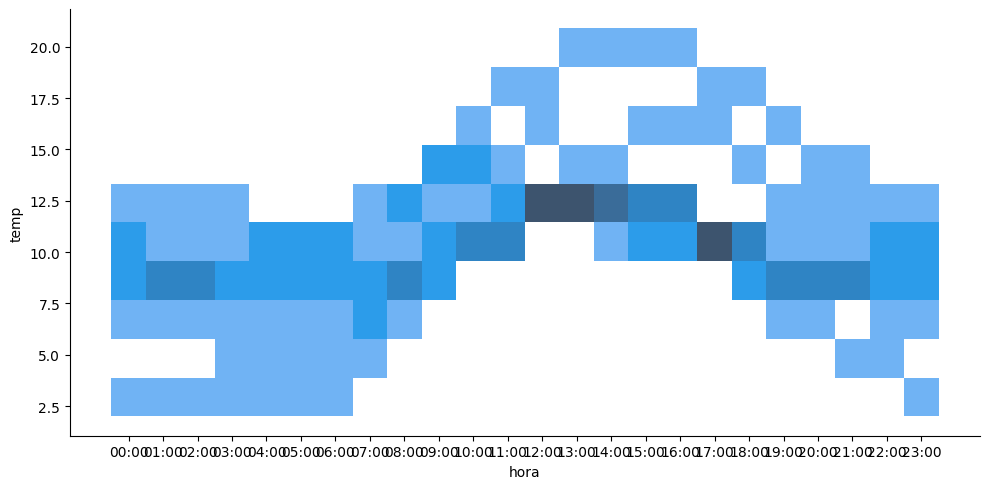

In [155]:
import seaborn as sns
import matplotlib as plt

sns.displot(x=meteo['hora'], 
            y=meteo['temp'],
            bins=10,
            aspect=2
            )